<a href="https://www.kaggle.com/code/metisa81/max-auxetic-ml-t4-safe?scriptVersionId=346803128" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# پیش‌بینی رفتار Auxetic در فازهای MAX (M₂AX) با یادگیری ماشین

این نوت‌بوک نسخه‌ی تمیز و بازطراحی‌شده‌ی آزمایش Auxetic پروژه است.

**هدف اصلی:** بررسی اینکه آیا می‌توان `Aniso_Poisson_Min` را از روی ترکیب شیمیایی پیش‌بینی کرد و مهم‌تر از آن، آیا مدل می‌تواند مواد دارای

\[
\nu_{\min}<0
\]

را به‌عنوان ماده‌ی **Auxetic** شناسایی کند.

### نکته‌ی مهم درباره‌ی GPU
این نوت‌بوک عمداً **GPU را استفاده نمی‌کند**. تمام مدل‌های XGBoost با CPU اجرا می‌شوند و `n_jobs=2` تنظیم شده‌اند تا روی Kaggle با **T4 / T4×2** هیچ تداخلی با CUDA، PyTorch یا bitsandbytes ایجاد نشود.

بنابراین برای این نوت‌بوک:
- GPU روشن یا خاموش باشد، تفاوتی ندارد.
- نیازی به `device='cuda'` نیست.
- نیازی به PyTorch، bitsandbytes یا CHGNet نیست.
- XGBoost با CPU اجرا می‌شود.

این انتخاب عمدی است، چون برای حدود ۵۵۰ نمونه، GPU نه تنها ضرورت ندارد، بلکه می‌تواند پیچیدگی بی‌فایده ایجاد کند.


In [4]:
# ============================================================
# ۰. نصب و Import
# ============================================================

!pip install -q pymatgen xgboost scikit-learn

import re
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import (
    KFold, StratifiedKFold, GroupKFold,
    RandomizedSearchCV, cross_val_predict
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor, XGBClassifier

RANDOM_STATE = 42

# فقط CPU
N_JOBS_MODEL = 2
N_JOBS_SEARCH = 1

DATA_DIR = "/kaggle/input/datasets/metisa81/elastic-properties"
OUT_DIR = "/kaggle/working"

print("آماده ✓")
print("XGBoost device: CPU")
print(f"Model threads: {N_JOBS_MODEL}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 15.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 82.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud

## ۱. بارگذاری داده و ساخت target

در این بخش همان منطق نوت‌بوک قبلی حفظ می‌شود:

- ترکیب واقعی از نام ماده مثل `Hf2BiN` استخراج می‌شود.
- عناصر M، A و X جداگانه به feature تبدیل می‌شوند.
- ساختار POSCAR برای feature هندسی استفاده نمی‌شود، چون POSCARهای موجود relax نشده و قالب مشترک دارند.
- فقط موادی وارد تحلیل می‌شوند که `Anisotropic_Mechanical_Properties` برایشان مقدار Min و Max پواسون را دارد.
- پایداری مکانیکی با همان برچسب VASPKIT فیلتر می‌شود.


In [5]:
# ============================================================
# ۱. بارگذاری VASPKIT و جدول عناصر
# ============================================================

def parse_formula(name):
    tokens = re.findall(r'[A-Z][a-z]?', name)
    if len(tokens) != 3:
        raise ValueError(f"فرمول غیرمنتظره: {name} -> {tokens}")
    return tokens  # M, A, X


with open(f"{DATA_DIR}/vaspkit_output.json", "r") as f:
    vk = json.load(f)

ptable = pd.read_csv(f"{DATA_DIR}/ptable2.csv").set_index("symbol")

ELEMENT_COLS = [
    'atomic_number',
    'atomic_radius',
    'covalent_radius_cordero',
    'atomic_weight',
    'density',
    'melting_point',
    'boiling_point',
    'en_pauling',
    'electron_affinity',
    'ionization_energy',
    'valance_main',
    'group_id',
    'period',
    'dipole_polarizability',
    'atomic_volume',
    'vdw_radius'
]

rows = []
skipped = []

for name, d in tqdm(vk.items(), desc="ساخت دیتاست"):
    # پایداری مکانیکی
    stability = d.get("Additional_Properties", {}).get("Mechanical_Stability")
    if stability != "Stable":
        continue

    aniso = d.get("Anisotropic_Mechanical_Properties", {}).get("Poisson's_Ratio_v")
    if not isinstance(aniso, dict):
        skipped.append((name, "missing anisotropic Poisson"))
        continue

    if "Min" not in aniso or "Max" not in aniso:
        skipped.append((name, "missing Min/Max"))
        continue

    try:
        m, a, x = parse_formula(name)
        if any(el not in ptable.index for el in (m, a, x)):
            skipped.append((name, "element missing in ptable"))
            continue

        row = {
            "material": name,
            "M": m,
            "A": a,
            "X": x
        }

        # ویژگی‌های هر سایت به‌صورت جداگانه
        for site, el in [('M', m), ('A', a), ('X', x)]:
            props = ptable.loc[el, ELEMENT_COLS]
            for c in ELEMENT_COLS:
                row[f"{site}_{c}"] = props[c]

        # همان featureهای تعاملی نسخه‌ی قبلی
        row["en_diff_MX"] = ptable.loc[m, "en_pauling"] - ptable.loc[x, "en_pauling"]
        row["en_diff_MA"] = ptable.loc[m, "en_pauling"] - ptable.loc[a, "en_pauling"]
        row["radius_ratio_AX"] = (
            ptable.loc[a, "covalent_radius_cordero"] /
            ptable.loc[x, "covalent_radius_cordero"]
        )
        row["M_enpauling_x_Mgroup"] = row["M_en_pauling"] * row["M_group_id"]
        row["M_ionize_x_A_valance"] = row["M_ionization_energy"] * row["A_valance_main"]
        row["endiffMX_x_radiusratio"] = row["en_diff_MX"] * row["radius_ratio_AX"]
        row["Mgroup_x_Agroup"] = row["M_group_id"] * row["A_group_id"]
        row["Menpauling_x_Aenpauling"] = row["M_en_pauling"] * row["A_en_pauling"]

        # VEC همان تعریف استفاده‌شده در پروژه
        row["VEC"] = (
            2 * row["M_group_id"] +
            row["A_valance_main"] +
            row["X_valance_main"]
        ) / 4

        row["VEC_x_endiffMX"] = row["VEC"] * row["en_diff_MX"]

        # Targets
        row["Aniso_Poisson_Min"] = float(aniso["Min"])
        row["Aniso_Poisson_Max"] = float(aniso["Max"])

        rows.append(row)

    except Exception as e:
        skipped.append((name, str(e)))

df = pd.DataFrame(rows).set_index("material")

FEATURE_COLS = [
    c for c in df.columns
    if c.startswith(("M_", "A_", "X_"))
    or c in [
        "en_diff_MX", "en_diff_MA", "radius_ratio_AX",
        "M_enpauling_x_Mgroup", "M_ionize_x_A_valance",
        "endiffMX_x_radiusratio", "Mgroup_x_Agroup",
        "Menpauling_x_Aenpauling", "VEC", "VEC_x_endiffMX"
    ]
]

print("=" * 70)
print(f"مواد نهایی: {len(df)}")
print(f"تعداد featureها: {len(FEATURE_COLS)}")
print(f"Auxetic واقعی: {(df['Aniso_Poisson_Min'] < 0).sum()} / {len(df)}")
print(f"درصد Auxetic: {(df['Aniso_Poisson_Min'] < 0).mean()*100:.2f}%")
print(f"موارد skip شده: {len(skipped)}")
print("=" * 70)


ساخت دیتاست:   0%|          | 0/553 [00:00<?, ?it/s]

مواد نهایی: 547
تعداد featureها: 58
Auxetic واقعی: 134 / 547
درصد Auxetic: 24.50%
موارد skip شده: 1


## ۲. کنترل اولیه‌ی target

قبل از آموزش مدل، توزیع `Aniso_Poisson_Min` و مرز Auxetic را بررسی می‌کنیم.

تعریف:

\[
y_{auxetic} =
\begin{cases}
1 & \nu_{min}<0\\
0 & \nu_{min}\ge 0
\end{cases}
\]

این target از مقدار DFT/VASPKIT ساخته شده و مدل شیمیایی نباید هیچ‌کدام از `Cij` یا Poisson را به‌عنوان feature ببیند.


count    547.000000
mean       0.060720
std        0.230301
min       -3.079000
25%        0.002000
50%        0.109000
75%        0.177500
max        0.312000
Name: Aniso_Poisson_Min, dtype: float64


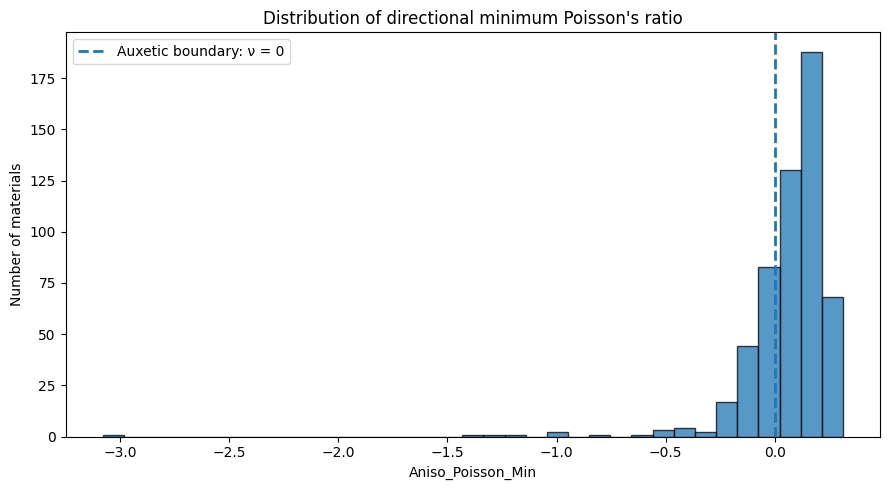

In [6]:
# ============================================================
# ۲. بررسی target
# ============================================================

y_reg = df["Aniso_Poisson_Min"].values
y_class = (y_reg < 0).astype(int)

print(df["Aniso_Poisson_Min"].describe())

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_reg, bins=35, edgecolor="black", alpha=0.75)
ax.axvline(0, linestyle="--", linewidth=2, label="Auxetic boundary: ν = 0")
ax.set_xlabel("Aniso_Poisson_Min")
ax.set_ylabel("Number of materials")
ax.set_title("Distribution of directional minimum Poisson's ratio")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/01_poisson_min_distribution.png", dpi=180, bbox_inches="tight")
plt.show()


## ۳. مدل اصلی: Chemical-only XGBoost

این مدل فقط اطلاعات شیمیایی M، A و X را می‌بیند.

هدف این آزمایش مهم است:

> آیا ماشین می‌تواند بدون دیدن تانسور الاستیک، ماده‌ای را که Poisson حداقل آن منفی است تشخیص دهد؟

برای جلوگیری از leakage، `Aniso_Poisson_Min`، `Aniso_Poisson_Max` و تمام خواص الاستیک از featureها حذف شده‌اند.


In [7]:
# ============================================================
# ۳. Chemical-only features
# ============================================================

X = df[FEATURE_COLS].copy()

FORBIDDEN = [
    "Aniso_Poisson_Min", "Aniso_Poisson_Max",
    "C11", "C12", "C13", "C33", "C44", "C66"
]

leak_cols = [c for c in X.columns if c in FORBIDDEN]
assert len(leak_cols) == 0, f"LEAKAGE DETECTED: {leak_cols}"

print(f"X shape = {X.shape}")
print("No Poisson/Cij target leakage detected ✓")


X shape = (547, 58)
No Poisson/Cij target leakage detected ✓


## ۴. کلاسیفایر Auxetic

به‌جای تکیه بر Accuracy تنها، معیارهای زیر گزارش می‌شوند:

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC

برای این مسئله **Recall و F1 برای کلاس Auxetic مهم‌اند**، چون نمی‌خواهیم مدل بیشتر مواد آگزتیک را از دست بدهد.


In [10]:
# ============================================================
# ۴. XGBoost Classifier
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

param_dist_clf = {
    "n_estimators": [150, 250, 350, 500, 700],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.015, 0.03, 0.05, 0.08, 0.12],
    "subsample": [0.65, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "min_child_weight": [1, 2, 4, 6],
    "gamma": [0, 0.05, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0.8, 1.0, 1.5, 2.0, 3.0]
}

base_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_MODEL
)

search_clf = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=param_dist_clf,
    n_iter=30,
    scoring="f1",
    cv=skf,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_SEARCH,
    refit=True,
    verbose=0
)

search_clf.fit(X, y_class)

best_clf = search_clf.best_estimator_

# OOF prediction برای ارزیابی منصفانه
oof_class = cross_val_predict(
    best_clf,
    X,
    y_class,
    cv=skf,
    method="predict",
    n_jobs=N_JOBS_SEARCH
)

oof_prob = cross_val_predict(
    best_clf,
    X,
    y_class,
    cv=skf,
    method="predict_proba",
    n_jobs=N_JOBS_SEARCH
)[:, 1]

acc = accuracy_score(y_class, oof_class)
prec = precision_score(y_class, oof_class, zero_division=0)
rec = recall_score(y_class, oof_class, zero_division=0)
f1 = f1_score(y_class, oof_class, zero_division=0)
roc = roc_auc_score(y_class, oof_prob)
pr_auc = average_precision_score(y_class, oof_prob)

print("Best parameters:")
print(search_clf.best_params_)
print("\nOOF classification performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print("\nClassification report:")
print(classification_report(
    y_class, oof_class,
    target_names=["Normal", "Auxetic"],
    zero_division=0
))

Best parameters:
{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 250, 'min_child_weight': 4, 'max_depth': 5, 'learning_rate': 0.12, 'gamma': 0.05, 'colsample_bytree': 0.75}

OOF classification performance:
Accuracy : 0.8574
Precision: 0.7545
Recall   : 0.6194
F1       : 0.6803
ROC-AUC  : 0.8404
PR-AUC   : 0.7286

Classification report:
              precision    recall  f1-score   support

      Normal       0.88      0.93      0.91       413
     Auxetic       0.75      0.62      0.68       134

    accuracy                           0.86       547
   macro avg       0.82      0.78      0.79       547
weighted avg       0.85      0.86      0.85       547



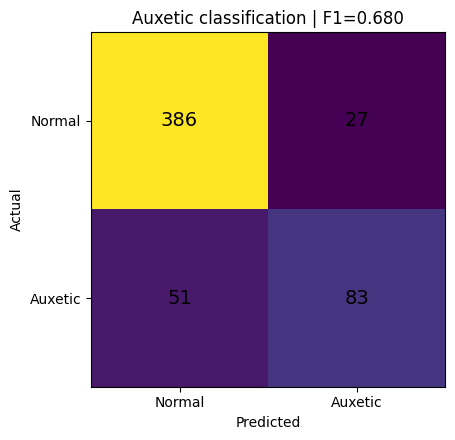

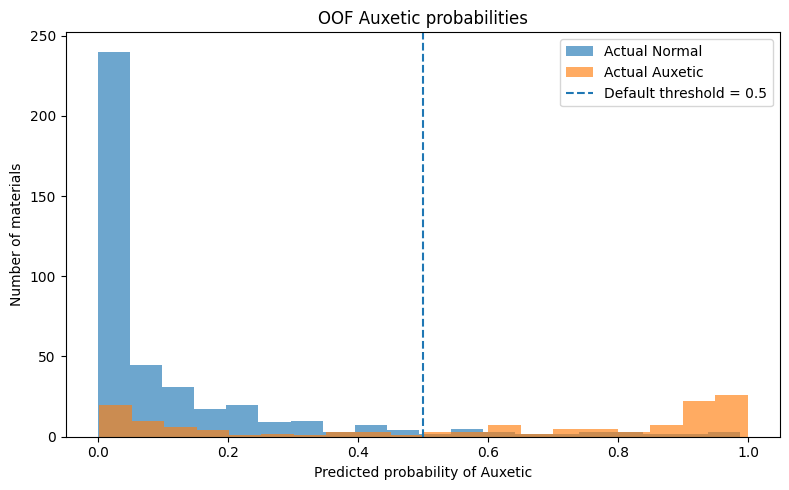

In [11]:
# ============================================================
# ۴.۵. Confusion Matrix + probability distribution
# ============================================================

cm = confusion_matrix(y_class, oof_class)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm)
ax.set_xticks([0, 1], ["Normal", "Auxetic"])
ax.set_yticks([0, 1], ["Normal", "Auxetic"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Auxetic classification | F1={f1:.3f}")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/02_auxetic_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(oof_prob[y_class == 0], bins=20, alpha=0.65, label="Actual Normal")
ax.hist(oof_prob[y_class == 1], bins=20, alpha=0.65, label="Actual Auxetic")
ax.axvline(0.5, linestyle="--", linewidth=1.5, label="Default threshold = 0.5")
ax.set_xlabel("Predicted probability of Auxetic")
ax.set_ylabel("Number of materials")
ax.set_title("OOF Auxetic probabilities")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/03_auxetic_probability_distribution.png", dpi=180, bbox_inches="tight")
plt.show()


## ۵. رگرسیون مستقیم `Aniso_Poisson_Min`

حالا مقدار عددی \(\nu_{min}\) را مستقیماً پیش‌بینی می‌کنیم.

این قسمت عمداً جدا از classification است. ممکن است مدل در تشخیص علامت عالی باشد ولی مقدار دقیق را با خطای قابل توجه پیش‌بینی کند. برای سؤال ما، این اتفاق لزوماً شکست نیست.

معیارها:

\[
MAE=\frac{1}{N}\sum_i|y_i-\hat y_i|
\]

و

\[
R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}
{\sum_i(y_i-\bar y)^2}.
\]


In [13]:
# ============================================================
# ۵. XGBoost Regressor برای ν_min
# ============================================================

param_dist_reg = {
    "n_estimators": [150, 250, 350, 500, 700],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.015, 0.03, 0.05, 0.08, 0.12],
    "subsample": [0.65, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "min_child_weight": [1, 2, 4, 6],
    "gamma": [0, 0.05, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0.8, 1.0, 1.5, 2.0, 3.0]
}

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

base_reg = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_MODEL
)

search_reg = RandomizedSearchCV(
    estimator=base_reg,
    param_distributions=param_dist_reg,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=kf,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_SEARCH,
    refit=True,
    verbose=0
)

search_reg.fit(X, y_reg)

best_reg = search_reg.best_estimator_

oof_reg = cross_val_predict(
    best_reg,
    X,
    y_reg,
    cv=kf,
    n_jobs=N_JOBS_SEARCH
)

mae = mean_absolute_error(y_reg, oof_reg)
rmse = np.sqrt(mean_squared_error(y_reg, oof_reg))
r2 = r2_score(y_reg, oof_reg)

print("Best parameters:")
print(search_reg.best_params_)
print("\nOOF regression performance:")
print(f"MAE : {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R²  : {r2:.5f}")

Best parameters:
{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 150, 'min_child_weight': 6, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.75}

OOF regression performance:
MAE : 0.10126
RMSE: 0.21756
R²  : 0.10598


In [14]:
# ============================================================
# ۵.۵. آیا مدل واقعاً مقدار منفی پیش‌بینی می‌کند؟
# ============================================================

actual_aux = y_reg < 0
pred_aux = oof_reg < 0

print("===== DIRECT REGRESSION AUXETIC TEST =====")
print(f"Actual auxetic materials : {actual_aux.sum()}")
print(f"Predicted negative       : {pred_aux.sum()}")
print(f"Correct negative         : {(actual_aux & pred_aux).sum()}")
print(f"Missed auxetic           : {(actual_aux & ~pred_aux).sum()}")
print(f"False negative prediction: {(~actual_aux & pred_aux).sum()}")

# classification metrics بر اساس علامت رگرسیون
print("\nClassification using regression sign:")
print(f"Accuracy: {accuracy_score(actual_aux, pred_aux):.4f}")
print(f"Precision: {precision_score(actual_aux, pred_aux, zero_division=0):.4f}")
print(f"Recall: {recall_score(actual_aux, pred_aux, zero_division=0):.4f}")
print(f"F1: {f1_score(actual_aux, pred_aux, zero_division=0):.4f}")

===== DIRECT REGRESSION AUXETIC TEST =====
Actual auxetic materials : 134
Predicted negative       : 127
Correct negative         : 83
Missed auxetic           : 51
False negative prediction: 44

Classification using regression sign:
Accuracy: 0.8263
Precision: 0.6535
Recall: 0.6194
F1: 0.6360


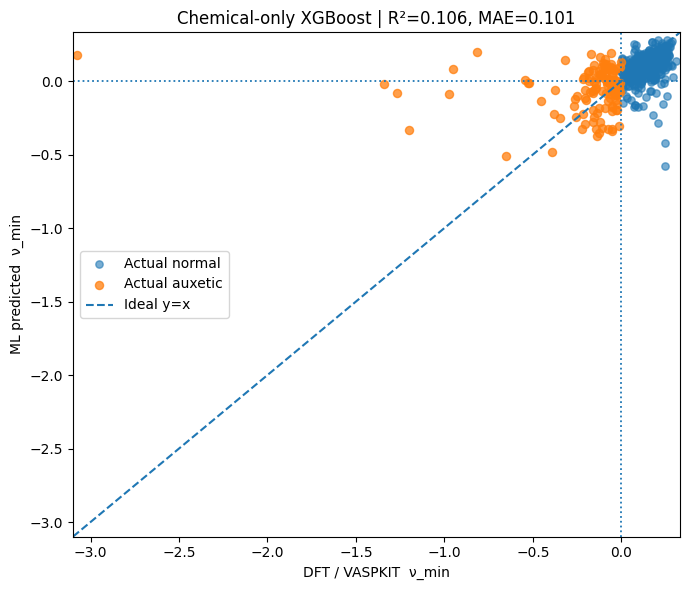

In [15]:
# ============================================================
# ۶. Parity plot: DFT vs ML
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

normal = y_reg >= 0
aux = y_reg < 0

ax.scatter(
    y_reg[normal], oof_reg[normal],
    alpha=0.60, s=28, label="Actual normal"
)
ax.scatter(
    y_reg[aux], oof_reg[aux],
    alpha=0.75, s=34, label="Actual auxetic"
)

lims = [
    min(y_reg.min(), oof_reg.min()) - 0.02,
    max(y_reg.max(), oof_reg.max()) + 0.02
]

ax.plot(lims, lims, "--", linewidth=1.5, label="Ideal y=x")
ax.axhline(0, linestyle=":", linewidth=1.3)
ax.axvline(0, linestyle=":", linewidth=1.3)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("DFT / VASPKIT  ν_min")
ax.set_ylabel("ML predicted  ν_min")
ax.set_title(f"Chemical-only XGBoost | R²={r2:.3f}, MAE={mae:.3f}")
ax.legend()

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/04_poisson_min_parity.png", dpi=200, bbox_inches="tight")
plt.show()


## ۷. آزمایش سخت‌تر: آیا مدل روی Mهای دیده‌نشده هم جواب می‌دهد؟

Random 5-fold ممکن است بیش از حد خوش‌بینانه باشد، چون ترکیبات شیمیایی مشابه در train و test قرار می‌گیرند.

برای آزمون سخت‌تر، گروه‌بندی را بر اساس عنصر M انجام می‌دهیم:

\[
\text{Group}=M
\]

در این حالت یک فلز انتقالی M در test می‌تواند کاملاً از train حذف شود.

این آزمون برای بررسی **generalization به chemistry جدید** مهم‌تر از random split است.


In [16]:
# ============================================================
# ۷. GroupKFold بر اساس M
# ============================================================

groups_M = df["M"].values

# اگر تعداد Mهای منحصربه‌فرد کمتر از 5 باشد، این بخش را متوقف می‌کنیم.
n_groups = df["M"].nunique()
print(f"تعداد عناصر M منحصربه‌فرد: {n_groups}")

if n_groups >= 5:
    gkf = GroupKFold(n_splits=5)

    group_clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device="cpu",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS_MODEL,
        **search_clf.best_params_
    )

    group_pred = cross_val_predict(
        group_clf,
        X,
        y_class,
        cv=gkf,
        groups=groups_M,
        method="predict",
        n_jobs=N_JOBS_SEARCH
    )

    print("===== GROUP-CV BY M =====")
    print(f"Accuracy : {accuracy_score(y_class, group_pred):.4f}")
    print(f"Precision: {precision_score(y_class, group_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_class, group_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_class, group_pred, zero_division=0):.4f}")
    print(classification_report(
        y_class, group_pred,
        target_names=["Normal", "Auxetic"],
        zero_division=0
    ))
else:
    print("تعداد گروه‌های M برای GroupKFold کافی نیست.")


تعداد عناصر M منحصربه‌فرد: 17
===== GROUP-CV BY M =====
Accuracy : 0.8355
Precision: 0.7115
Recall   : 0.5522
F1       : 0.6218
              precision    recall  f1-score   support

      Normal       0.86      0.93      0.89       413
     Auxetic       0.71      0.55      0.62       134

    accuracy                           0.84       547
   macro avg       0.79      0.74      0.76       547
weighted avg       0.83      0.84      0.83       547



## ۸. Feature Importance

در این قسمت بررسی می‌کنیم مدل شیمیایی از چه ویژگی‌هایی بیشتر استفاده کرده است.

این بخش برای تفسیر فیزیکی مهم است، اما **feature importance به‌تنهایی رابطه‌ی علّی را ثابت نمی‌کند**.


M_melting_point         0.128910
X_atomic_number         0.092909
radius_ratio_AX         0.050724
A_group_id              0.041212
Mgroup_x_Agroup         0.037161
A_valance_main          0.031952
M_ionize_x_A_valance    0.029545
X_ionization_energy     0.027388
VEC                     0.024262
X_atomic_weight         0.020913
X_atomic_volume         0.020638
X_atomic_radius         0.019993
M_atomic_radius         0.019392
X_valance_main          0.018560
M_atomic_number         0.017270
A_vdw_radius            0.016963
A_en_pauling            0.016871
M_density               0.015883
A_atomic_weight         0.015570
A_ionization_energy     0.015433
dtype: float32


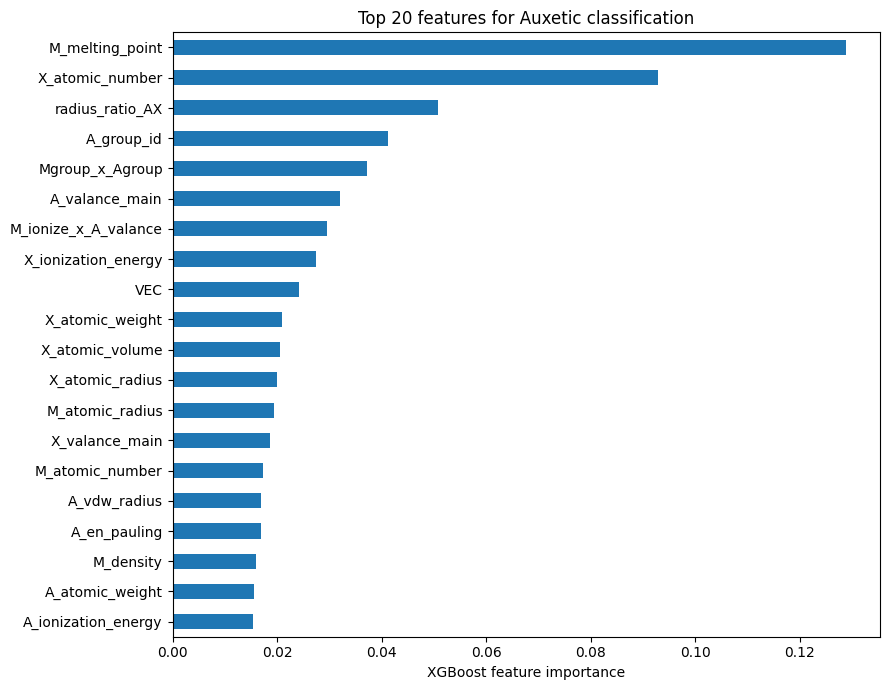

In [17]:
# ============================================================
# ۸. Feature importance
# ============================================================

# مدل نهایی روی کل داده fit می‌شود، فقط برای تفسیر و prediction مواد جدید
clf_final = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_MODEL,
    **search_clf.best_params_
)
clf_final.fit(X, y_class)

importance = pd.Series(
    clf_final.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False).head(20)

print(importance)

fig, ax = plt.subplots(figsize=(9, 7))
importance.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("XGBoost feature importance")
ax.set_title("Top 20 features for Auxetic classification")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/05_auxetic_feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()


## ۹. مقایسه‌ی سه تعریف مدل

برای فهم مکانیزم، یک مقایسه‌ی مهم انجام می‌دهیم:

1. **Chemical-only:** فقط ترکیب شیمیایی
2. **Chemical + VEC:** همان ویژگی‌ها، با VEC
3. **Elastic-informed:** استفاده از descriptorهای الاستیک

مدل سوم برای اثبات اینکه elastic anisotropy حامل سیگنال است مفید است، اما نباید با مدل اول اشتباه گرفته شود. اگر هدف پیش‌بینی یک ماده‌ی جدید قبل از محاسبه‌ی DFT باشد، مدل Chemical-only مدل واقعیِ مورد نیاز است.


In [18]:
# ============================================================
# ۹. Elastic-informed benchmark
# ============================================================

# این ستون‌ها فقط برای benchmark هستند و نباید وارد Chemical-only شوند.
elastic_cols = [
    "C11", "C12", "C13", "C33", "C44", "C66"
]

# از JSON، Cij را به دیتافریم اضافه می‌کنیم
elastic_map = {}

for name, d in vk.items():
    if name not in df.index:
        continue
    cij = d.get("Elastic_Tensor_Voigt", {})
    if all(k in cij for k in elastic_cols):
        elastic_map[name] = [cij[k] for k in elastic_cols]

elastic_df = pd.DataFrame.from_dict(
    elastic_map, orient="index", columns=elastic_cols
)

common = df.index.intersection(elastic_df.index)

X_elastic = df.loc[common, FEATURE_COLS].copy()
for c in elastic_cols:
    X_elastic[c] = elastic_df.loc[common, c]

# نسبت‌های مهم از تحلیل قبلی
X_elastic["C44_C11"] = X_elastic["C44"] / X_elastic["C11"]
X_elastic["C33_C11"] = X_elastic["C33"] / X_elastic["C11"]
X_elastic["C13_norm"] = X_elastic["C13"] / np.sqrt(
    X_elastic["C11"] * X_elastic["C33"]
)

y_elastic = (df.loc[common, "Aniso_Poisson_Min"] < 0).astype(int)

elastic_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_MODEL,
    n_estimators=350,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85
)

elastic_pred = cross_val_predict(
    elastic_model,
    X_elastic,
    y_elastic,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method="predict",
    n_jobs=N_JOBS_SEARCH
)

print("===== ELASTIC-INFORMED BENCHMARK =====")
print(f"Accuracy : {accuracy_score(y_elastic, elastic_pred):.4f}")
print(f"Precision: {precision_score(y_elastic, elastic_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_elastic, elastic_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_elastic, elastic_pred, zero_division=0):.4f}")


===== ELASTIC-INFORMED BENCHMARK =====
Accuracy : 0.9378
Precision: 0.9167
Recall   : 0.8209
F1       : 0.8661


## ۱۰. پیش‌بینی یک ماده‌ی MAX جدید

این تابع فقط برای **Chemical-only model** است، بنابراین برای یک ترکیب جدید لازم نیست Cij را بدانیم.

مثلاً:

`Hf2BiN`

خروجی:
- احتمال Auxetic بودن
- پیش‌بینی مستقیم \(\nu_{min}\)
- برچسب Auxetic/Normal


In [19]:
# ============================================================
# ۱۰. تابع پیش‌بینی ماده‌ی جدید
# ============================================================

def featurize_formula(formula):
    tokens = re.findall(r'[A-Z][a-z]?', formula)
    if len(tokens) != 3:
        raise ValueError(
            f"{formula}: فرمول باید دقیقاً سه عنصر M-A-X داشته باشد."
        )

    m, a, x = tokens

    for el in (m, a, x):
        if el not in ptable.index:
            raise ValueError(f"عنصر {el} در ptable2.csv پیدا نشد.")

    row = {}

    for site, el in [('M', m), ('A', a), ('X', x)]:
        props = ptable.loc[el, ELEMENT_COLS]
        for c in ELEMENT_COLS:
            row[f"{site}_{c}"] = props[c]

    row["en_diff_MX"] = ptable.loc[m, "en_pauling"] - ptable.loc[x, "en_pauling"]
    row["en_diff_MA"] = ptable.loc[m, "en_pauling"] - ptable.loc[a, "en_pauling"]
    row["radius_ratio_AX"] = (
        ptable.loc[a, "covalent_radius_cordero"] /
        ptable.loc[x, "covalent_radius_cordero"]
    )
    row["M_enpauling_x_Mgroup"] = row["M_en_pauling"] * row["M_group_id"]
    row["M_ionize_x_A_valance"] = row["M_ionization_energy"] * row["A_valance_main"]
    row["endiffMX_x_radiusratio"] = row["en_diff_MX"] * row["radius_ratio_AX"]
    row["Mgroup_x_Agroup"] = row["M_group_id"] * row["A_group_id"]
    row["Menpauling_x_Aenpauling"] = row["M_en_pauling"] * row["A_en_pauling"]

    row["VEC"] = (
        2 * row["M_group_id"] +
        row["A_valance_main"] +
        row["X_valance_main"]
    ) / 4

    row["VEC_x_endiffMX"] = row["VEC"] * row["en_diff_MX"]

    feat = pd.Series(row).reindex(FEATURE_COLS)

    if feat.isna().any():
        raise ValueError(
            f"Feature missing for {formula}: {feat[feat.isna()].index.tolist()}"
        )

    return feat.to_frame().T


def predict_new_material(formula):
    X_new = featurize_formula(formula)

    prob = float(clf_final.predict_proba(X_new)[0, 1])
    cls = prob >= 0.5
    pred_nu = float(best_reg.predict(X_new)[0])

    print("=" * 60)
    print(f"Material: {formula}")
    print(f"Auxetic probability : {prob*100:.1f}%")
    print(f"Classifier           : {'AUXETIC ✓' if cls else 'NORMAL'}")
    print(f"Predicted ν_min      : {pred_nu:.4f}")
    print(f"Regression sign      : {'NEGATIVE ✓' if pred_nu < 0 else 'POSITIVE'}")
    print("=" * 60)

    return {
        "formula": formula,
        "auxetic_probability": prob,
        "classifier_auxetic": bool(cls),
        "predicted_nu_min": pred_nu
    }


# نمونه
result = predict_new_material("Hf2BiN")


Material: Hf2BiN
Auxetic probability : 67.8%
Classifier           : AUXETIC ✓
Predicted ν_min      : 0.0302
Regression sign      : POSITIVE


## ۱۱. تست مستقیم روی مواد Auxetic شناخته‌شده

اینجا مهم‌ترین خروجی پژوهشی را می‌گیریم.

برای تمام مواد واقعی Auxetic، مقدار DFT و مقدار ML را کنار هم می‌گذاریم و مشخص می‌کنیم:

- چند ماده واقعاً منفی بوده‌اند؛
- چند ماده مدل هم منفی پیش‌بینی کرده؛
- کدام مواد بیشترین خطا را دارند؛
- آیا مدل مواد شدیداً Auxetic را بهتر تشخیص می‌دهد یا فقط مواد نزدیک صفر را.


In [20]:
# ============================================================
# ۱۱. جدول Auxetic materials
# ============================================================

aux_results = pd.DataFrame({
    "material": df.index,
    "M": df["M"].values,
    "A": df["A"].values,
    "X": df["X"].values,
    "DFT_nu_min": y_reg,
    "ML_nu_min": oof_reg,
    "ML_auxetic_by_regression": oof_reg < 0,
    "ML_auxetic_probability": oof_prob
}).set_index("material")

aux_results["absolute_error"] = np.abs(
    aux_results["DFT_nu_min"] - aux_results["ML_nu_min"]
)

aux_only = aux_results[aux_results["DFT_nu_min"] < 0].sort_values(
    "DFT_nu_min"
)

print(f"تعداد مواد Auxetic واقعی: {len(aux_only)}")
print(
    f"تعداد مواد Auxetic که regression آنها را منفی پیش‌بینی کرده: "
    f"{aux_only['ML_auxetic_by_regression'].sum()}"
)

display(aux_only.head(30))

aux_only.to_csv(
    f"{OUT_DIR}/auxetic_material_predictions.csv"
)


تعداد مواد Auxetic واقعی: 134
تعداد مواد Auxetic که regression آنها را منفی پیش‌بینی کرده: 83


,M,A,X,DFT_nu_min,ML_nu_min,ML_auxetic_by_regression,ML_auxetic_probability,absolute_error
material,,,,,,,,
Mo2SnN,Mo,Sn,N,-3.079,0.179677,False,0.002175,3.258677
Hf2ZnS,Hf,Zn,S,-1.340,-0.019050,True,0.613974,1.320950
Zr2SnP,Zr,Sn,P,-1.269,-0.083910,True,0.967606,1.185090
Hf2GeP,Hf,Ge,P,-1.199,-0.334726,True,0.985116,0.864274
Sc2SbSi,Sc,Sb,Si,-0.973,-0.086134,True,0.977412,0.886866
V2SnN,V,Sn,N,-0.952,0.079933,False,0.111472,1.031933
Cr2PN,Cr,P,N,-0.816,0.198712,False,0.029218,1.014712
Hf2SiP,Hf,Si,P,-0.652,-0.511098,True,0.992818,0.140902
Sc2BiP,Sc,Bi,P,-0.544,0.007077,False,0.979935,0.551077


## ۱۲. جمع‌بندی نهایی

این نوت‌بوک باید به سه سؤال جدا جواب بدهد:

### سؤال ۱
آیا chemistry-only ML می‌تواند \(\nu_{min}\) را پیش‌بینی کند؟

با `MAE`, `RMSE`, `R²`.

### سؤال ۲
آیا مدل می‌تواند Auxetic بودن را تشخیص دهد؟

با `F1`, `Recall`, `PR-AUC`.

### سؤال ۳
آیا مدل واقعاً می‌تواند **عدد منفی** برای یک ماده‌ی Auxetic تولید کند؟

با مقایسه‌ی مستقیم:

\[
\nu_{min}^{DFT}<0
\qquad\text{در برابر}\qquad
\nu_{min}^{ML}<0
\]

اگر این اتفاق با نرخ بالا رخ دهد، شواهد مهمی داریم که اطلاعات شیمیایی موجود در composition descriptors برای یادگیری Auxeticity سیگنال دارد.

اگر Chemical-only ضعیف باشد ولی Elastic-informed قوی باشد، نتیجه‌ی فیزیکی متفاوتی به دست می‌آید:

> Auxeticity بیشتر یک پیامد emergent از elastic anisotropy است تا چیزی که بتوان آن را مستقیماً از ترکیب شیمیایی تشخیص داد.

**برای مقاله، GroupKFold بر اساس M باید گزارش شود و Random 5-fold به‌تنهایی کافی نیست.**
